# E-commerce Sales Analysis

## Project Overview

This project analyzes fictional e-commerce sales data to understand sales performance, customer behavior, product performance, sales channels, discounts, monthly trends, and customer locations.

### Tools
- Python
- Pandas
- Matplotlib

### Dataset
- 800 orders
- 12 columns
- January–September 2026
- Fictional e-commerce data

In [26]:
import pandas as pd

df = pd.read_csv("ecommerce_sales.csv")

df.head()

,Order_ID,Customer_ID,Order_Date,Product,Category,Customer_Type,Sales_Channel,Quantity,Unit_Price,Discount,Revenue,Customer_City
0,ORD0001,C0292,2026/7/26,Coffee Maker,Home & Kitchen,New,Online,1,7600,0.00,7600,Kamakura
1,ORD0002,C0274,2026/7/22,Jeans,Clothing,New,Marketplace,2,7600,0.00,15200,Utsunomiya
2,ORD0003,C0288,2026/6/11,Wireless Mouse,Electronics,New,Mobile App,1,3500,0.00,3500,Mito
3,ORD0004,C0118,2026/7/17,Wireless Headphones,Electronics,Returning,Mobile App,1,8500,0.05,8075,Tsukuba
4,ORD0005,C0082,2026/8/2,Wireless Mouse,Electronics,Returning,Mobile App,3,3500,0.10,9450,Funabashi


In [27]:
print(df.shape)

(800, 12)


In [28]:
print(df.head())

  Order_ID Customer_ID Order_Date              Product        Category  \
0  ORD0001       C0292  2026/7/26         Coffee Maker  Home & Kitchen   
1  ORD0002       C0274  2026/7/22                Jeans        Clothing   
2  ORD0003       C0288  2026/6/11       Wireless Mouse     Electronics   
3  ORD0004       C0118  2026/7/17  Wireless Headphones     Electronics   
4  ORD0005       C0082   2026/8/2       Wireless Mouse     Electronics   

  Customer_Type Sales_Channel  Quantity  Unit_Price  Discount  Revenue  \
0           New        Online         1        7600      0.00     7600   
1           New   Marketplace         2        7600      0.00    15200   
2           New    Mobile App         1        3500      0.00     3500   
3     Returning    Mobile App         1        8500      0.05     8075   
4     Returning    Mobile App         3        3500      0.10     9450   

  Customer_City  
0      Kamakura  
1    Utsunomiya  
2          Mito  
3       Tsukuba  
4     Funabashi  


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       800 non-null    object 
 1   Customer_ID    800 non-null    object 
 2   Order_Date     800 non-null    object 
 3   Product        800 non-null    object 
 4   Category       800 non-null    object 
 5   Customer_Type  800 non-null    object 
 6   Sales_Channel  800 non-null    object 
 7   Quantity       800 non-null    int64  
 8   Unit_Price     800 non-null    int64  
 9   Discount       800 non-null    float64
 10  Revenue        800 non-null    int64  
 11  Customer_City  800 non-null    object 
dtypes: float64(1), int64(3), object(8)
memory usage: 75.1+ KB


In [30]:
df.isnull().sum()

Order_ID         0
Customer_ID      0
Order_Date       0
Product          0
Category         0
Customer_Type    0
Sales_Channel    0
Quantity         0
Unit_Price       0
Discount         0
Revenue          0
Customer_City    0
dtype: int64

In [31]:
df["Order_ID"].duplicated().sum()

np.int64(0)

In [33]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [34]:
df["Order_Date"].dtype

dtype('<M8[ns]')

In [35]:
df[["Quantity","Unit_Price","Discount","Revenue"]].describe()

,Quantity,Unit_Price,Discount,Revenue
count,800.000000,800.000000,800.000000,800.000000
mean,1.657500,6311.375000,0.073438,9858.637500
std,0.871001,2832.501004,0.058325,7391.921288
min,1.000000,2400.000000,0.000000,1920.000000
25%,1.000000,3800.000000,0.000000,4582.500000
50%,1.000000,5900.000000,0.050000,7565.000000
75%,2.000000,7825.000000,0.100000,12800.000000
max,4.000000,12800.000000,0.200000,51200.000000


In [36]:
total_revenue = df["Revenue"].sum()
print(total_revenue)

7886910


In [37]:
average_revenue =df["Revenue"].mean()
print(average_revenue)

9858.6375


In [38]:
total_quantity = df["Quantity"].sum()
print(total_quantity)

1326


In [39]:
average_quantity = df["Quantity"].mean()
print(average_quantity)

1.6575


In [40]:
highest_order_revenue = df["Revenue"].max()
print(highest_order_revenue)

51200


In [41]:
lowest_order_revenue = df["Revenue"].min()
print(lowest_order_revenue)

1920


In [42]:
revenue_by_category = (
    df.groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
print(revenue_by_category)

Category
Electronics       2300660
Clothing          1867160
Home & Kitchen    1364380
Sports            1257145
Beauty            1097565
Name: Revenue, dtype: int64


In [43]:
avg_revenue_by_category = (
    df.groupby("Category")["Revenue"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_revenue_by_category)

Category
Clothing          11743.144654
Electronics       11114.299517
Sports             9977.341270
Home & Kitchen     8859.610390
Beauty             7127.045455
Name: Revenue, dtype: float64


In [44]:
order_count_by_cateogry = (
    df.groupby("Category")["Order_ID"]
    .count()
    .sort_values(ascending=False)
)
print(order_count_by_cateogry)

Category
Electronics       207
Clothing          159
Beauty            154
Home & Kitchen    154
Sports            126
Name: Order_ID, dtype: int64


In [45]:
revenue_by_customer = (
    df.groupby("Customer_Type")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
print(revenue_by_customer)

Customer_Type
New          4662655
Returning    3224255
Name: Revenue, dtype: int64


In [46]:
avg_revenue_by_customer = (
    df.groupby("Customer_Type")["Revenue"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_revenue_by_customer)

Customer_Type
Returning    10075.796875
New           9713.864583
Name: Revenue, dtype: float64


In [48]:
order_count_by_customer = (
    df.groupby("Customer_Type")["Order_ID"]
    .count()
    .sort_values(ascending=False)
)
print(order_count_by_customer)

Customer_Type
New          480
Returning    320
Name: Order_ID, dtype: int64


In [49]:
revenue_by_channel = (
    df.groupby("Sales_Channel")["Revenue"]
    .sum()
    .sort_values(ascending = False)
)
print(revenue_by_channel)

Sales_Channel
Online         3937980
Mobile App     2541850
Marketplace    1407080
Name: Revenue, dtype: int64


In [50]:
order_count_by_channel = (
    df.groupby("Sales_Channel")["Order_ID"]
    .count()
    .sort_values(ascending=False)
)
print(order_count_by_channel)

Sales_Channel
Online         395
Mobile App     259
Marketplace    146
Name: Order_ID, dtype: int64


In [50]:
avg_revenue_by_channel = (
    df.groupby("Sales_Channel")["Revenue"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_revenue_by_channel)

Sales_Channel
Online         9969.569620
Mobile App     9814.092664
Marketplace    9637.534247
Name: Revenue, dtype: float64


In [51]:
order_count_by_discount = (
    df.groupby("Discount")["Order_ID"]
    .count()
    .sort_values(ascending=False)
)
print(order_count_by_discount)

Discount
0.10    237
0.05    211
0.00    204
0.15    102
0.20     46
Name: Order_ID, dtype: int64


In [52]:
revenue_by_discount = (
    df.groupby("Discount")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
print(revenue_by_discount)

Discount
0.10    2355480
0.00    2333500
0.05    1953390
0.15     856460
0.20     388080
Name: Revenue, dtype: int64


In [53]:
avg_revenue_by_discount = (
    df.groupby("Discount")["Revenue"]
    .mean()
    .sort_values(ascending =False)
)
print(avg_revenue_by_discount)

Discount
0.00    11438.725490
0.10     9938.734177
0.05     9257.772512
0.20     8436.521739
0.15     8396.666667
Name: Revenue, dtype: float64


In [54]:
lowest_avg_revenue_discount = (
    df.groupby("Discount")["Revenue"]
    .mean()
    .sort_values(ascending = True)
)
print(lowest_avg_revenue_discount)

Discount
0.15     8396.666667
0.20     8436.521739
0.05     9257.772512
0.10     9938.734177
0.00    11438.725490
Name: Revenue, dtype: float64


In [55]:
monthly_revenue = (
    df.groupby(df["Order_Date"].dt.month)["Revenue"]
    .sum()
    .sort_values(ascending = False)
)
print(monthly_revenue)

Order_Date
1    1021890
6     929500
9     905465
5     891280
7     884365
8     869745
3     829760
4     799215
2     755690
Name: Revenue, dtype: int64


In [56]:
monthly_order_count = (
    df.groupby(df["Order_Date"].dt.month)["Order_ID"]
    .count()
    .sort_values(ascending=False)
)
print(monthly_order_count)

Order_Date
1    106
9     98
3     90
6     90
8     89
5     88
7     88
2     77
4     74
Name: Order_ID, dtype: int64


In [57]:
monthly_avg_revenue = (
    df.groupby(df["Order_Date"].dt.month)["Revenue"]
    .mean()
    .sort_values(ascending=False)
)
print(monthly_avg_revenue)

Order_Date
4    10800.202703
6    10327.777778
5    10128.181818
7    10049.602273
2     9814.155844
8     9772.415730
1     9640.471698
9     9239.438776
3     9219.555556
Name: Revenue, dtype: float64


In [58]:
revenue_by_city = (
    df.groupby("Customer_City")["Revenue"]
    .sum()
    .sort_values(ascending =False)
)
print(revenue_by_city)

Customer_City
Tsukuba       675675
Kawagoe       651125
Hachioji      650590
Kawasaki      585660
Saitama       567520
Tokyo         557770
Takasaki      545035
Mito          520405
Kashiwa       494650
Chiba         492415
Maebashi      467670
Funabashi     459220
Utsunomiya    445840
Kamakura      423875
Yokohama      349460
Name: Revenue, dtype: int64


In [63]:
order_count_by_city=(
    df.groupby("Customer_City")["Order_ID"]
    .count()
    .sort_values(ascending = False)
)
print(order_count_by_city)

Customer_City
Kawagoe       60
Tsukuba       60
Saitama       58
Takasaki      58
Tokyo         57
Kashiwa       56
Hachioji      55
Maebashi      55
Chiba         53
Kamakura      52
Kawasaki      51
Funabashi     48
Yokohama      47
Mito          45
Utsunomiya    45
Name: Order_ID, dtype: int64


In [59]:
avg_revenue_by_city = (
    df.groupby("Customer_City")["Revenue"]
    .mean()
    .sort_values(ascending = False)
)
print(avg_revenue_by_city)

Customer_City
Hachioji      11828.909091
Mito          11564.555556
Kawasaki      11483.529412
Tsukuba       11261.250000
Kawagoe       10852.083333
Utsunomiya     9907.555556
Tokyo          9785.438596
Saitama        9784.827586
Funabashi      9567.083333
Takasaki       9397.155172
Chiba          9290.849057
Kashiwa        8833.035714
Maebashi       8503.090909
Kamakura       8151.442308
Yokohama       7435.319149
Name: Revenue, dtype: float64


In [60]:
category_channel_revenue = (
    df.groupby(["Category","Sales_Channel"])["Revenue"]
    .sum()
    .unstack()
)
print(category_channel_revenue)

Sales_Channel   Marketplace  Mobile App   Online
Category                                        
Beauty               222530      383260   491775
Clothing             364935      648355   853870
Electronics          304270      744845  1251545
Home & Kitchen       282390      401060   680930
Sports               232955      364330   659860


In [61]:
customer_channel_revenue = (
    df.groupby(["Customer_Type","Sales_Channel"])["Revenue"]
    .sum()
    .unstack()
)
print(customer_channel_revenue)

Sales_Channel  Marketplace  Mobile App   Online
Customer_Type                                  
New                 857235     1426285  2379135
Returning           549845     1115565  1558845


In [62]:
revenue_by_product = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
print(revenue_by_product)

Product
Smart Watch            981120
Jacket                 589375
Wireless Headphones    487050
Running Shoes          472420
Sneakers               418745
Jeans                  404320
Skincare Set           392760
Air Fryer              359660
Coffee Maker           347700
Bluetooth Speaker      328910
Sports Bag             324800
Table Lamp             287820
Hair Dryer             263840
Wireless Mouse         263550
Beauty Mirror          253125
USB-C Hub              240030
Dumbbell Set           238280
Hoodie                 236000
T-Shirt                218720
Storage Box Set        191360
Electric Kettle        177840
Facial Cleanser        137200
Yoga Mat               111150
Fitness Band           110495
Body Lotion             50640
Name: Revenue, dtype: int64


In [63]:
avg_revenue_by_product = (
    df.groupby("Product")["Revenue"]
    .mean()
    .sort_values(ascending = False)
)
print(avg_revenue_by_product)

Product
Smart Watch            20874.893617
Jacket                 19645.833333
Air Fryer              15637.391304
Running Shoes          14763.125000
Wireless Headphones    13529.166667
Sneakers               13085.781250
Jeans                  12635.000000
Dumbbell Set           12541.052632
Skincare Set           11551.764706
Coffee Maker           11216.129032
Bluetooth Speaker       9966.969697
Sports Bag              9552.941176
Hoodie                  9076.923077
Hair Dryer              8794.666667
Table Lamp              7995.000000
Electric Kettle         7732.173913
Beauty Mirror           7031.250000
USB-C Hub               5854.390244
T-Shirt                 5608.205128
Yoga Mat                5557.500000
Wireless Mouse          5271.000000
Fitness Band            5261.666667
Storage Box Set         4667.317073
Facial Cleanser         4035.294118
Body Lotion             2532.000000
Name: Revenue, dtype: float64


In [64]:
order_count_by_product = (
    df.groupby("Product")["Order_ID"]
    .count()
    .sort_values(ascending = False)
)
print(order_count_by_product)

Product
Wireless Mouse         50
Smart Watch            47
Storage Box Set        41
USB-C Hub              41
T-Shirt                39
Wireless Headphones    36
Table Lamp             36
Beauty Mirror          36
Skincare Set           34
Sports Bag             34
Facial Cleanser        34
Bluetooth Speaker      33
Sneakers               32
Jeans                  32
Running Shoes          32
Coffee Maker           31
Jacket                 30
Hair Dryer             30
Hoodie                 26
Air Fryer              23
Electric Kettle        23
Fitness Band           21
Body Lotion            20
Yoga Mat               20
Dumbbell Set           19
Name: Order_ID, dtype: int64


In [65]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
print(df["Order_Date"].dtype)

datetime64[ns]


In [66]:
monthly_revenue = (
    df.groupby(df["Order_Date"].dt.month)["Revenue"]
    .sum()
    .sort_values()
)
print(monthly_revenue)

Order_Date
2     755690
4     799215
3     829760
8     869745
7     884365
5     891280
9     905465
6     929500
1    1021890
Name: Revenue, dtype: int64


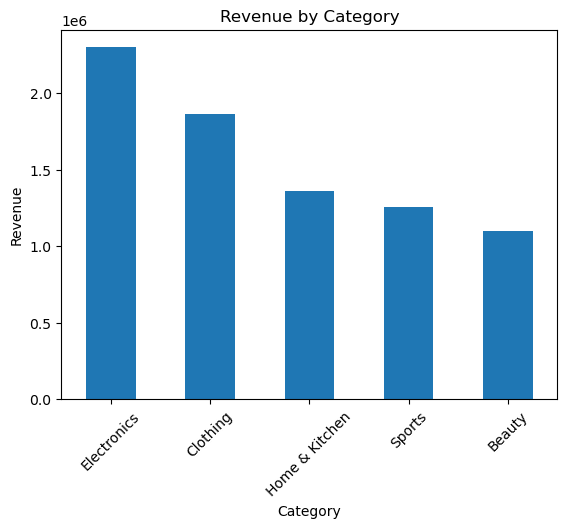

In [21]:
import matplotlib.pyplot as plt
revenue_by_category.plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

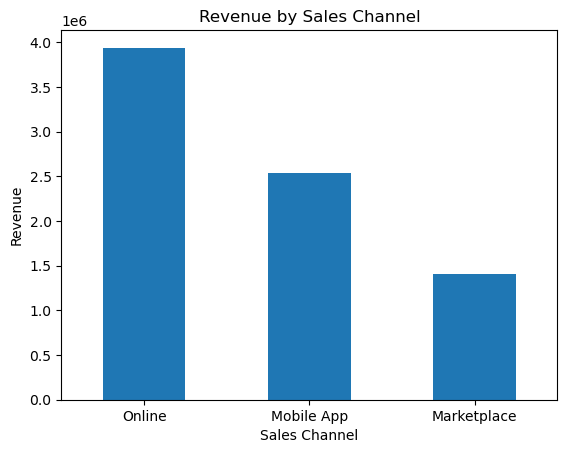

In [68]:
revenue_by_channel.plot(kind="bar")
plt.title("Revenue by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Revenue")
plt.xticks(rotation =0)
plt.show()

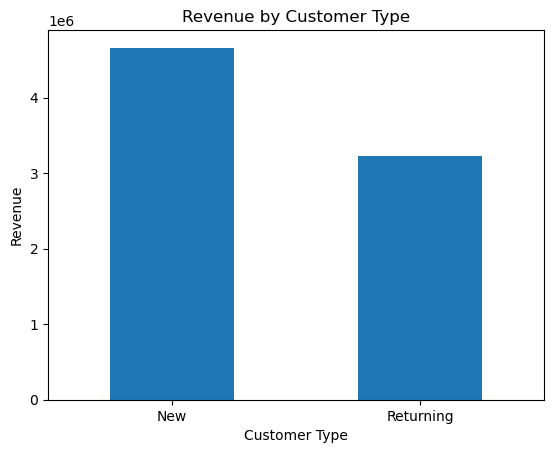

In [69]:
revenue_by_customer.plot(kind="bar")
plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Revenue")
plt.xticks(rotation = 0)
plt.show()

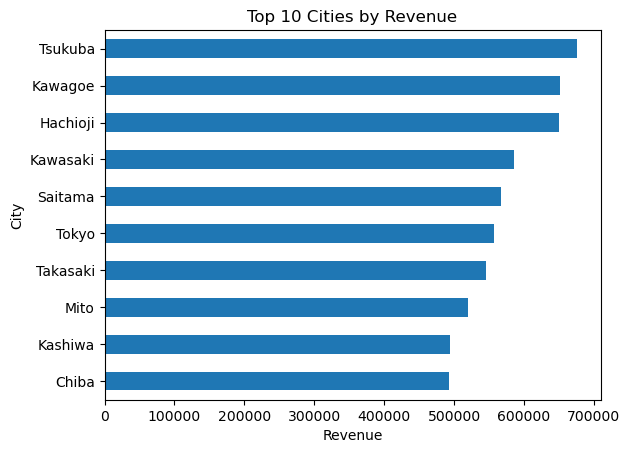

In [70]:
revenue_by_city.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Cities by Revenue")
plt.xlabel("Revenue")
plt.ylabel("City")
plt.show()

In [79]:
monthly_revenue = (
    df.groupby(df["Order_Date"].dt.month)["Revenue"]
    .sum()
    .sort_index()
)

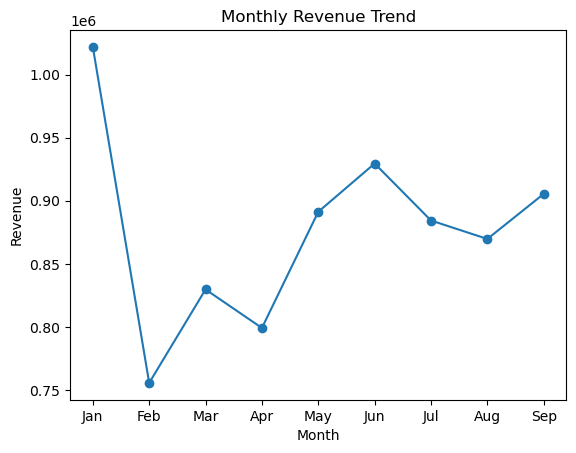

In [86]:
monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(
    range(1, 10),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep"]
)

plt.show()

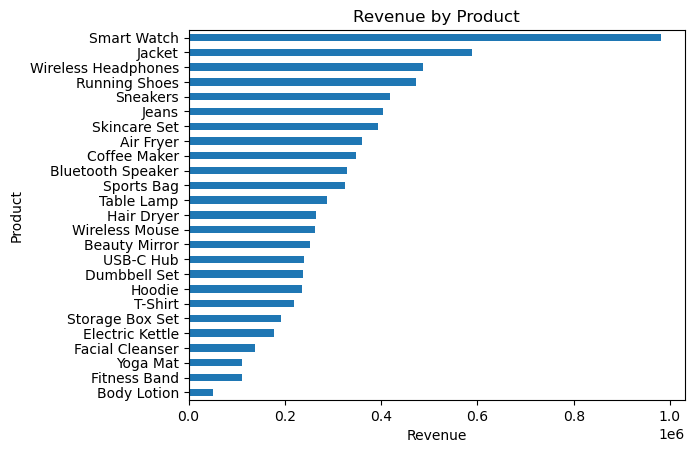

In [87]:
revenue_by_product.sort_values().plot(kind="barh")
plt.title("Revenue by Product")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

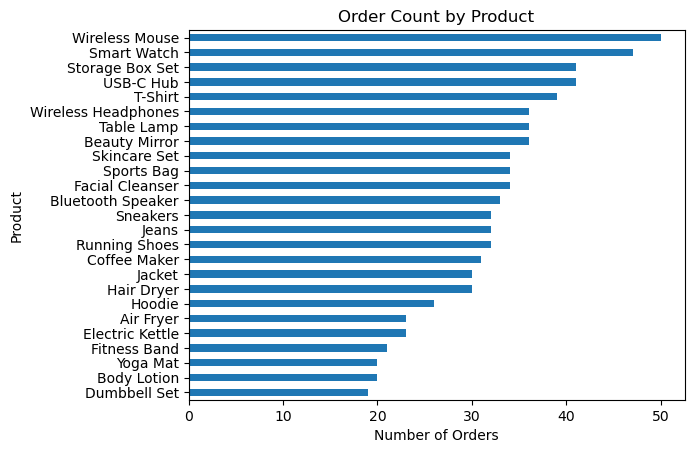

In [88]:
order_count_by_product.sort_values().plot(kind="barh")
plt.title("Order Count by Product")
plt.xlabel("Number of Orders")
plt.ylabel("Product")
plt.show()

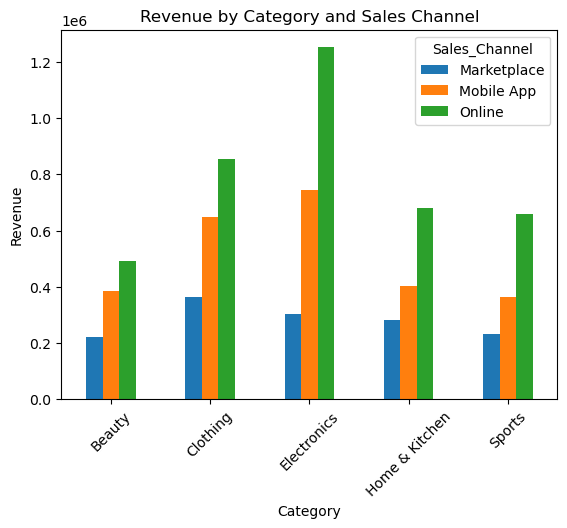

In [89]:
category_channel_revenue.plot(kind="bar")
plt.title("Revenue by Category and Sales Channel")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.show()

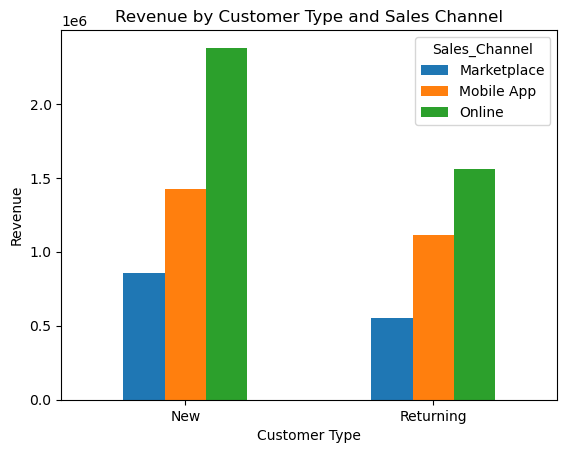

In [90]:
customer_channel_revenue.plot(kind="bar")
plt.title("Revenue by Customer Type and Sales Channel")
plt.xlabel("Customer Type")
plt.ylabel("Revenue")
plt.xticks(rotation = 0)
plt.show()

## Key Findings

- Electronics generated the highest total revenue and had the most orders among categories.
- Clothing had the highest average revenue per order.
- New customers generated more total revenue and placed more orders, while Returning customers had a higher average revenue per order.
- Online was the highest-revenue sales channel and had the most orders.
- The 10% discount level had the most orders and the highest total revenue.
- January had the highest total revenue and order count, while April had the highest average revenue per order.
- Tsukuba had the highest total revenue, Kawagoe had the most orders, and Hachioji had the highest average revenue per order.
- Smart Watch generated the highest total revenue and average revenue per order, while Wireless Mouse had the most orders.